Pre-trained VIT for Image Classification

In [2]:
import torch
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import requests

#using standard base 16x16 VIT from hf
model_name = 'google/vit-base-patch16-224'
processor = ViTImageProcessor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(model_name)

#requirement to use gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

#load and resize image
image_path = '/kaggle/input/datasets/shehryarasiflone/test-image/crochet.jpg' 
image = Image.open(image_path).convert('RGB')
inputs = processor(images=image, return_tensors="pt").to(device)

#running the computation and prediction
with torch.no_grad():
    outputs = model(**inputs)

#extracting the top prediction from the individual logits
logits = outputs.logits
predicted_class_idx = logits.argmax(-1).item()
predicted_label = model.config.id2label[predicted_class_idx]

print(f"The top prediction is: {predicted_label}")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

The top prediction is: vase


Visualising Patch Attention 

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

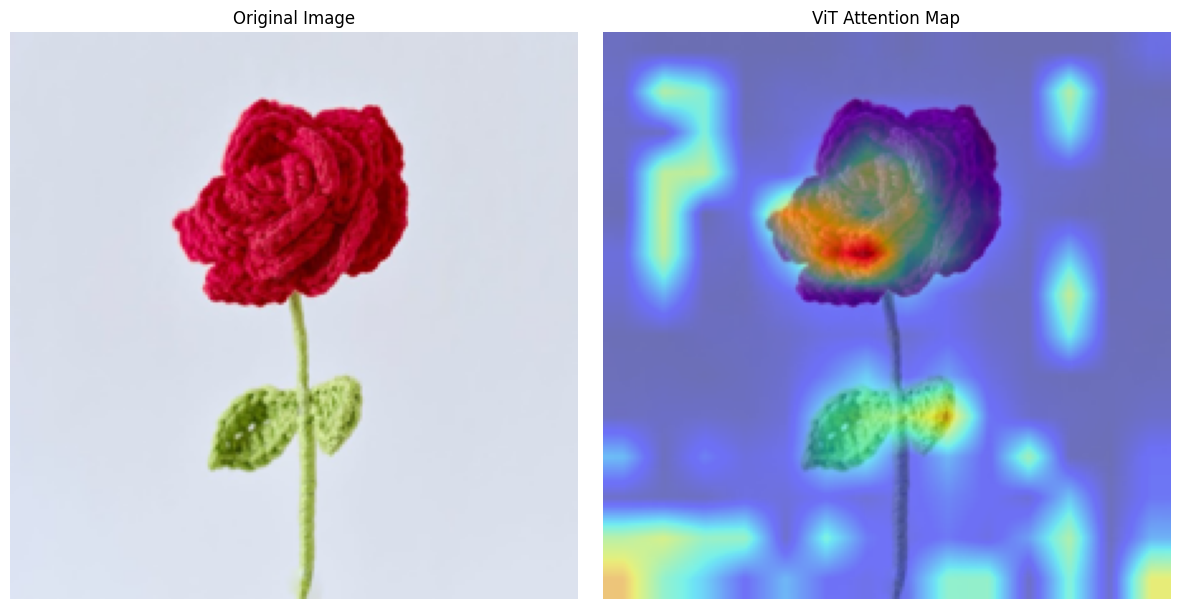

In [8]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
#reloading the model but eager cuz cant extract weights otherwise
model = ViTForImageClassification.from_pretrained(
    model_name, 
    attn_implementation="eager"
)
model.to(device)
model.eval()

#forward pass with attentions being stored
with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)

#only store the attention matrix from last layer
attention = outputs.attentions[-1] 

#averaging all attention heads
attention = attention.mean(dim=1) 

#taking out only the cls tokens attention against all patches giving a single vector
cls_attention = attention[0, 0, 1:] 

#reshape the vector into a grid 14x14
cls_attention = cls_attention.reshape(14, 14).cpu().numpy()

#normalising so values only between 0 and 1 for visualisation
cls_attention = (cls_attention - cls_attention.min()) / (cls_attention.max() - cls_attention.min())

#resize to 224x224 to match original image size
attention_map = cv2.resize(cls_attention, (224, 224))

#create figure and plot both on top of each other with the attentiongrid as a heatmap
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

resized_original = image.resize((224, 224))

ax[0].imshow(resized_original)
ax[0].set_title('Original Image')
ax[0].axis('off')

#red means high attention and blue means low
ax[1].imshow(resized_original)
ax[1].imshow(attention_map, cmap='jet', alpha=0.5) 
ax[1].set_title('ViT Attention Map')
ax[1].axis('off')

plt.tight_layout()
plt.show()

Patch Masking

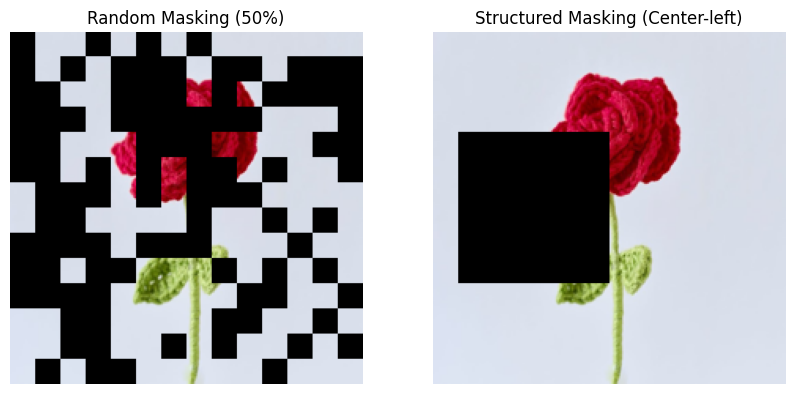

Prediction for Random Masking: vase
Prediction for Structured Masking: bonnet, poke bonnet


In [17]:
import random
import copy

#function to mask images by turing pixels to black
def mask_image(img, mask_indices, patch_size=16):
    masked_img = np.array(img.resize((224, 224)))
    for idx in mask_indices:
        # Calculate grid coordinates (14x14 grid)
        row = idx // 14
        col = idx % 14
        # Calculate pixel coordinates
        y_start, y_end = row * patch_size, (row + 1) * patch_size
        x_start, x_end = col * patch_size, (col + 1) * patch_size
        # Set the patch to black
        masked_img[y_start:y_end, x_start:x_end] = 0
    return Image.fromarray(masked_img)

#first random patch masking that removes half the patches
num_patches_to_mask = int(196 * 0.5)
random_mask_indices = random.sample(range(196), num_patches_to_mask)
random_masked_image = mask_image(image, random_mask_indices)

#then a structured mask that removes the most important centre left 6x6 grid
structured_mask_indices = []
for r in range(4, 10):     # Center rows
    for c in range(1, 7): # Center-left cols
        structured_mask_indices.append(r * 14 + c)
structured_masked_image = mask_image(image, structured_mask_indices)

#plotting masked images to see what is being input
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(random_masked_image)
ax[0].set_title('Random Masking (50%)')
ax[0].axis('off')

ax[1].imshow(structured_masked_image)
ax[1].set_title('Structured Masking (Center-left)')
ax[1].axis('off')
plt.show()

#evaluating and predicting random image
inputs_random = processor(images=random_masked_image, return_tensors="pt").to(device)
with torch.no_grad():
    logits_random = model(**inputs_random).logits
pred_idx_random = logits_random.argmax(-1).item()
print(f"Prediction for Random Masking: {model.config.id2label[pred_idx_random]}")

#evaluating and predicting structured image
inputs_structured = processor(images=structured_masked_image, return_tensors="pt").to(device)
with torch.no_grad():
    logits_structured = model(**inputs_structured).logits
pred_idx_structured = logits_structured.argmax(-1).item()
print(f"Prediction for Structured Masking: {model.config.id2label[pred_idx_structured]}")

CLS vs Mean-Pooled Patch Linear Probes

In [3]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader


vit_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset = torchvision.datasets.CIFAR10(root='/kaggle/input/datasets/shehryarasiflone/cifar-10', train=True, download=True, transform=vit_transforms)
val_dataset = torchvision.datasets.CIFAR10(root='/kaggle/input/datasets/shehryarasiflone/cifar-10', train=False, download=True, transform=vit_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("DataLoaders are ready")

DataLoaders are ready


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np
import torch

#extract both types
def extract_features(dataloader, model, max_batches=20):
    cls_features = []
    mean_features = []
    all_labels = []
    
    model.eval()
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloader):
            if i >= max_batches:
                break
                
            inputs = inputs.to(device)
            
            if hasattr(model, 'vit'):
                outputs = model.vit(inputs)
            else:
                outputs = model(inputs)
            
            #last hidden state extracted
            last_hidden = outputs.last_hidden_state
            
            #cls token extracted
            cls_token = last_hidden[:, 0, :].cpu().numpy()
            
            #all patch tkens and averaging
            patch_tokens = last_hidden[:, 1:, :]
            mean_pooled = patch_tokens.mean(dim=1).cpu().numpy()
            
            cls_features.append(cls_token)
            mean_features.append(mean_pooled)
            all_labels.append(labels.numpy())
            
    return np.vstack(cls_features), np.vstack(mean_features), np.concatenate(all_labels)

print("Extracting training features...")
#20 batches train
X_train_cls, X_train_mean, y_train = extract_features(train_loader, model, max_batches=20)

print("Extracting validation features...")
#10 batches validation
X_val_cls, X_val_mean, y_val = extract_features(val_loader, model, max_batches=10)

print("Training Linear Probes...")

#train and test cls
clf_cls = LogisticRegression(max_iter=900)
clf_cls.fit(X_train_cls, y_train)
cls_pred = clf_cls.predict(X_val_cls)
cls_acc = accuracy_score(y_val, cls_pred)

#train and test mean pool
clf_mean = LogisticRegression(max_iter=900)
clf_mean.fit(X_train_mean, y_train)
mean_pred = clf_mean.predict(X_val_mean)
mean_acc = accuracy_score(y_val, mean_pred)

print(f"\n[CLS] Token Linear Probe Accuracy: {cls_acc * 100:.2f}%")
print(f"Mean-Pooled Patches Linear Probe Accuracy: {mean_acc * 100:.2f}%")

Extracting training features...
Extracting validation features...
Training Linear Probes...

[CLS] Token Linear Probe Accuracy: 94.06%
Mean-Pooled Patches Linear Probe Accuracy: 95.00%
